In [ ]:
# connect drive to collab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install emoji

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.3/356.3 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.5.1-py2.py3-none-any.whl size=351210 sha256=5666d4305ed8fe981b8b48c18da8ce37102c9a0f35a48acba07201807923a8e9
  Stored in directory: /root/.cache/pip/wheels/51/92/44/e2ef13f803aa08711819357e6de0c5fe67b874671141413565
Successfully built emoji


In [ ]:
import pandas as pd
import re
import nltk
import typing
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from typing import List
from string import punctuation
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import emoji
import matplotlib.pyplot as plt
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
def preprocess_text(text):
    text = re.sub(r'\W+', ' ', text)  # Remove non-alphanumeric characters

    text = re.sub(r'\d+', '', text)  # Remove numbers

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs

    text = emoji.demojize(text)  # Convert emojis to text equivalents

    text = text.lower() # Convert text to lowercase

    tokens = word_tokenize(text) # Tokenize the text into words

    stop_words = set(stopwords.words('english') + stopwords.words('arabic') + list(punctuation) + ["al", "one", "said", "news", "also", "people"]) # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]

    lemmatizer = WordNetLemmatizer() # Lemmatize the words
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    #stemmer = PorterStemmer() # Stem words in text
    #tokens = [stemmer.stem(token) for token in tokens]

    # remove_words = ['al', 'egypt', 'people', 'egyptian', 'case', 'number', 'post', 'world', 'picture', 'said', 'one', 'news', 'widely', 'saying', 'circulated', 'country', 'new', 'comment', 'day', 'say', 'year', 'thousand', 'million', 'two', 'page', 'first', 'announced', 'state', 'pound', 'many', 'statement', 'time']
    # pattern = r'\b(?:{})\b'.format('|'.join(map(re.escape, remove_words))) # remove specific words with regex
    # processed_text = re.sub(pattern, '', text)

    processed_text = ' '.join(tokens) # Join the tokens back into a single string

    return processed_text

In [ ]:
with open ("/content/drive/MyDrive/AFH Project/AFH_brief.txt") as file:
    brief = file.read()

In [ ]:
preprocessed_brief = preprocess_text(brief)

In [ ]:
def load_emotion_lexicon(lexicon_path):
    lexicon = {}
    with open(lexicon_path, 'r') as file:
        for line in file:
            if line.strip() != '':
                word, emotion, score = line.strip().split('\t')
                if word not in lexicon:
                    lexicon[word] = {}
                lexicon[word][emotion] = int(score)
    return lexicon

lexicon_path = '/content/drive/MyDrive/AFH Project/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'
emotion_lexicon = load_emotion_lexicon(lexicon_path)

In [ ]:
def get_emotion_scores(text, emotion_lexicon):
    scores = {emotion: 0 for emotion in emotion_lexicon['anger']}
    words = text.lower().split()
    for word in words:
        if word in emotion_lexicon:
            for emotion, score in emotion_lexicon[word].items():
                scores[emotion] += score
    return scores

emotion_scores_brief = get_emotion_scores(preprocessed_brief, emotion_lexicon)
print(emotion_scores_brief)

{'anger': 7184, 'anticipation': 11751, 'disgust': 4034, 'fear': 13522, 'joy': 7506, 'negative': 17382, 'positive': 25287, 'sadness': 9377, 'surprise': 4859, 'trust': 18647}


In [ ]:
def find_top_words_by_emotion(text, emotion_lexicon, target_emotion, top_n=20):
    words = text.lower().split()
    emotion_word_scores = {}
    for word in words:
        if word in emotion_lexicon and target_emotion in emotion_lexicon[word]:
            score = emotion_lexicon[word][target_emotion]
            if word not in emotion_word_scores:
                emotion_word_scores[word] = score
            else:
                emotion_word_scores[word] += score
    sorted_words = sorted(emotion_word_scores.items(), key=lambda x: x[1], reverse=True)
    top_words = [word for word, _ in sorted_words[:top_n]]
    return top_words

target_emotion_anger = 'anger'
target_emotion_disgust = 'disgust'
target_emotion_fear = 'fear'
target_emotion_sadness = 'sadness'
target_emotion_negative = 'negative'

top_n = 20

top_words_anger = find_top_words_by_emotion(preprocessed_brief, emotion_lexicon, target_emotion_anger, top_n)
print(top_words_anger)

top_words_disgust = find_top_words_by_emotion(preprocessed_brief, emotion_lexicon, target_emotion_disgust, top_n)
print(top_words_disgust)

top_words_fear = find_top_words_by_emotion(preprocessed_brief, emotion_lexicon, target_emotion_fear, top_n)
print(top_words_fear)

top_words_sadness = find_top_words_by_emotion(preprocessed_brief, emotion_lexicon, target_emotion_sadness, top_n)
print(top_words_sadness)

top_words_negative = find_top_words_by_emotion(preprocessed_brief, emotion_lexicon, target_emotion_negative, top_n)
print(top_words_negative)

['death', 'pound', 'injury', 'force', 'disease', 'terrorist', 'money', 'soldier', 'epidemic', 'youth', 'attack', 'fee', 'confront', 'revolution', 'armed', 'killing', 'court', 'fear', 'defense', 'prison']
['death', 'disease', 'terrorist', 'epidemic', 'interior', 'lord', 'treat', 'cancer', 'misleading', 'prosecution', 'remains', 'prisoner', 'terrorism', 'criminal', 'failure', 'sentence', 'subsidy', 'collapse', 'desert', 'sham']
['case', 'death', 'hospital', 'god', 'infection', 'government', 'medical', 'injury', 'injured', 'force', 'disease', 'urgent', 'military', 'police', 'terrorist', 'quarantine', 'prevent', 'fire', 'martyr', 'watch']
['case', 'death', 'hospital', 'injury', 'isolation', 'injured', 'disease', 'negative', 'terrorist', 'mother', 'leave', 'martyr', 'soldier', 'rumor', 'epidemic', 'emergency', 'closure', 'revolution', 'killing', 'prison']
['virus', 'case', 'death', 'pound', 'infection', 'government', 'injury', 'isolation', 'injured', 'force', 'disease', 'urgent', 'player', 

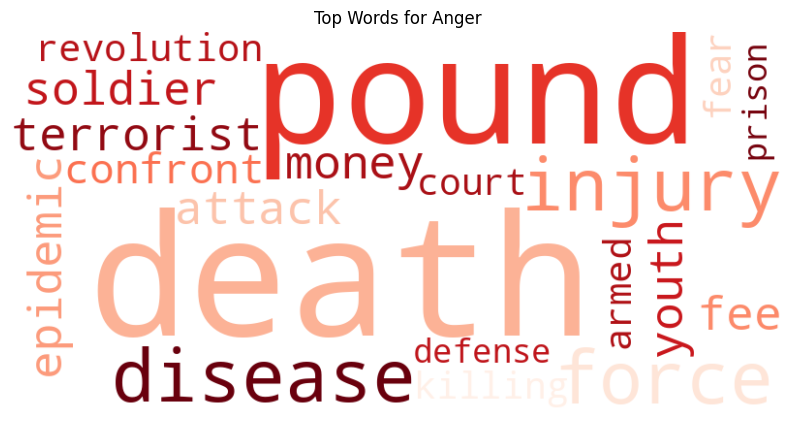

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_anger, target_emotion_anger)

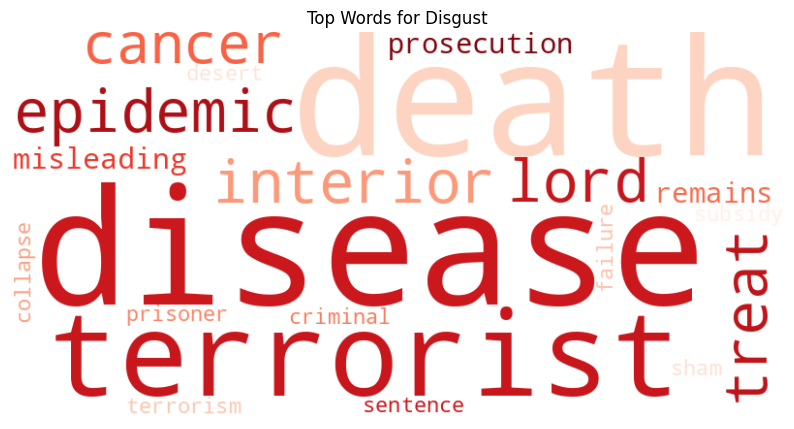

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_disgust, target_emotion_disgust)

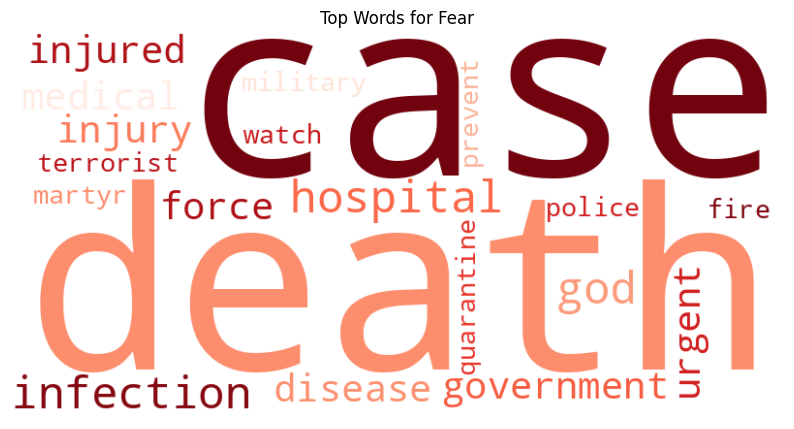

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_fear, target_emotion_fear)

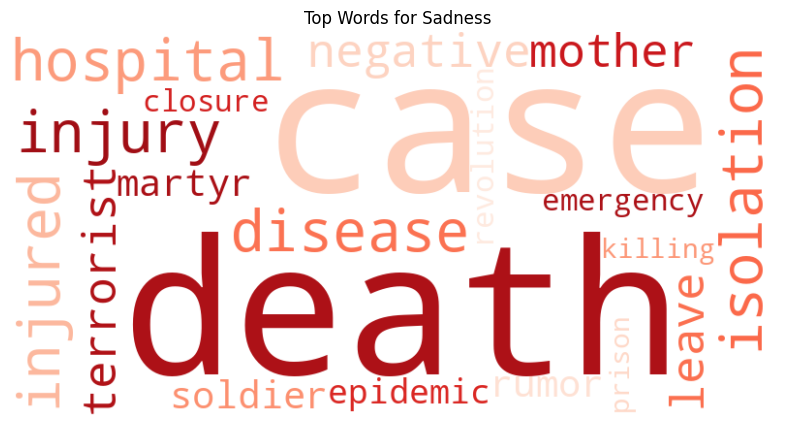

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_sadness, target_emotion_sadness)

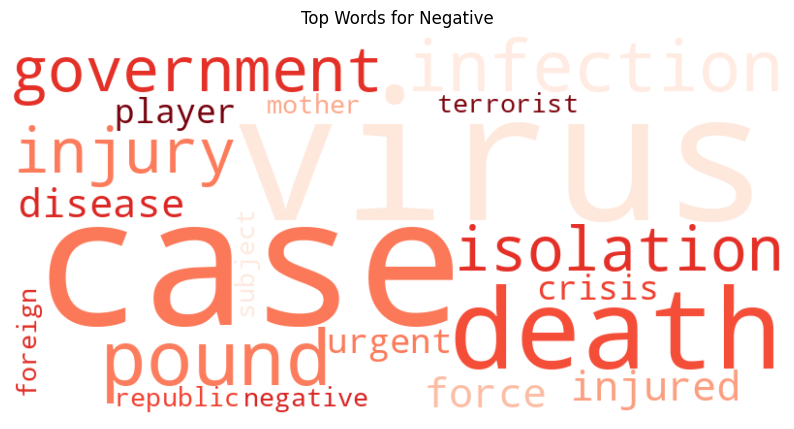

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_negative, target_emotion_negative)

In [ ]:
with open ("/content/drive/MyDrive/AFH Project/AFH_returns.txt") as file:
    returns = file.read()

In [ ]:
preprocessed_returns = preprocess_text(returns)

In [ ]:
def get_emotion_scores(text, emotion_lexicon):
    scores = {emotion: 0 for emotion in emotion_lexicon['anger']}
    words = text.lower().split()
    for word in words:
        if word in emotion_lexicon:
            for emotion, score in emotion_lexicon[word].items():
                scores[emotion] += score
    return scores

emotion_scores_return = get_emotion_scores(preprocessed_returns, emotion_lexicon)
print(emotion_scores_return)

{'anger': 12661, 'anticipation': 18392, 'disgust': 6361, 'fear': 18674, 'joy': 11988, 'negative': 30087, 'positive': 47118, 'sadness': 13909, 'surprise': 6881, 'trust': 37063}


In [ ]:
def find_top_words_by_emotion(text, emotion_lexicon, target_emotion, top_n=20):
    words = text.lower().split()
    emotion_word_scores = {}
    for word in words:
        if word in emotion_lexicon and target_emotion in emotion_lexicon[word]:
            score = emotion_lexicon[word][target_emotion]
            if word not in emotion_word_scores:
                emotion_word_scores[word] = score
            else:
                emotion_word_scores[word] += score
    sorted_words = sorted(emotion_word_scores.items(), key=lambda x: x[1], reverse=True)
    top_words = [word for word, _ in sorted_words[:top_n]]
    return top_words

target_emotion_anger = 'anger'
target_emotion_disgust = 'disgust'
target_emotion_fear = 'fear'
target_emotion_sadness = 'sadness'
target_emotion_negative = 'negative'

top_n = 20

top_words_anger_r = find_top_words_by_emotion(preprocessed_returns, emotion_lexicon, target_emotion_anger, top_n)
print(top_words_anger)

top_words_disgust_r = find_top_words_by_emotion(preprocessed_returns, emotion_lexicon, target_emotion_disgust, top_n)
print(top_words_disgust)

top_words_fear_r = find_top_words_by_emotion(preprocessed_returns, emotion_lexicon, target_emotion_fear, top_n)
print(top_words_fear)

top_words_sadness_r = find_top_words_by_emotion(preprocessed_returns, emotion_lexicon, target_emotion_sadness, top_n)
print(top_words_sadness)

top_words_negative_r = find_top_words_by_emotion(preprocessed_returns, emotion_lexicon, target_emotion_negative, top_n)
print(top_words_negative)

['death', 'pound', 'injury', 'force', 'disease', 'terrorist', 'money', 'soldier', 'epidemic', 'youth', 'attack', 'fee', 'confront', 'revolution', 'armed', 'killing', 'court', 'fear', 'defense', 'prison']
['death', 'disease', 'terrorist', 'epidemic', 'interior', 'lord', 'treat', 'cancer', 'misleading', 'prosecution', 'remains', 'prisoner', 'terrorism', 'criminal', 'failure', 'sentence', 'subsidy', 'collapse', 'desert', 'sham']
['case', 'death', 'hospital', 'god', 'infection', 'government', 'medical', 'injury', 'injured', 'force', 'disease', 'urgent', 'military', 'police', 'terrorist', 'quarantine', 'prevent', 'fire', 'martyr', 'watch']
['case', 'death', 'hospital', 'injury', 'isolation', 'injured', 'disease', 'negative', 'terrorist', 'mother', 'leave', 'martyr', 'soldier', 'rumor', 'epidemic', 'emergency', 'closure', 'revolution', 'killing', 'prison']
['virus', 'case', 'death', 'pound', 'infection', 'government', 'injury', 'isolation', 'injured', 'force', 'disease', 'urgent', 'player', 

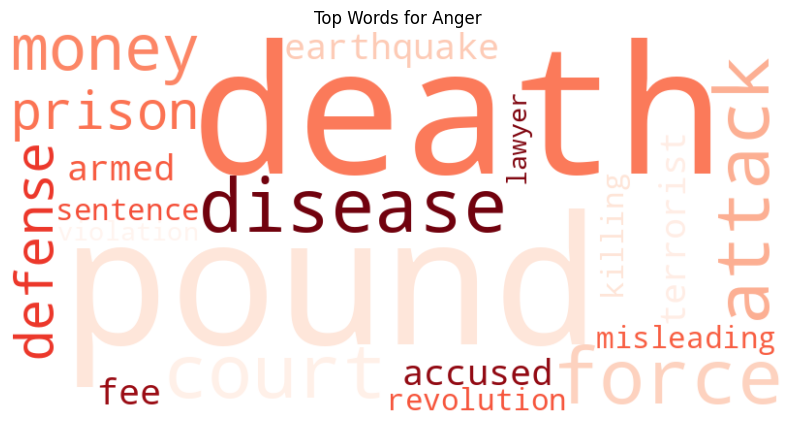

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_anger_r, target_emotion_anger)

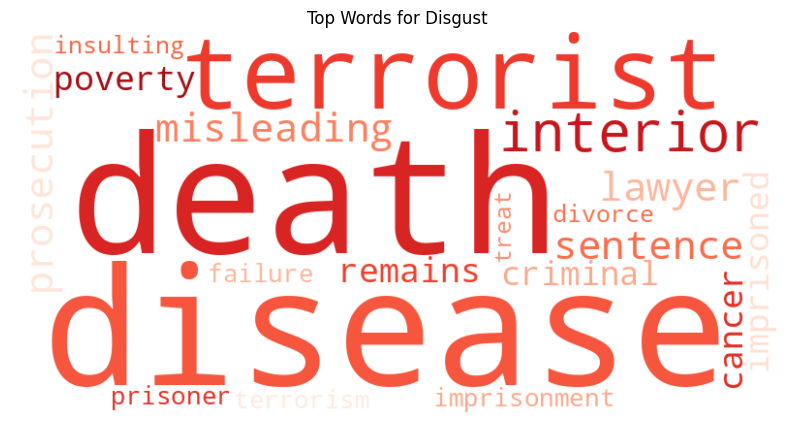

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_disgust_r, target_emotion_disgust)

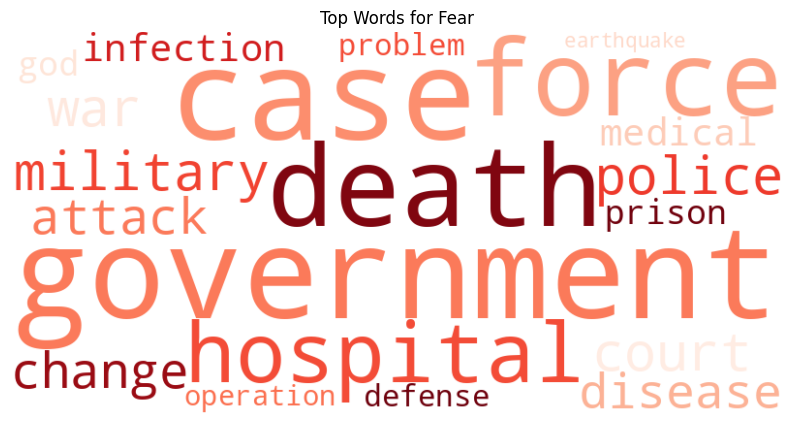

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_fear_r, target_emotion_fear)

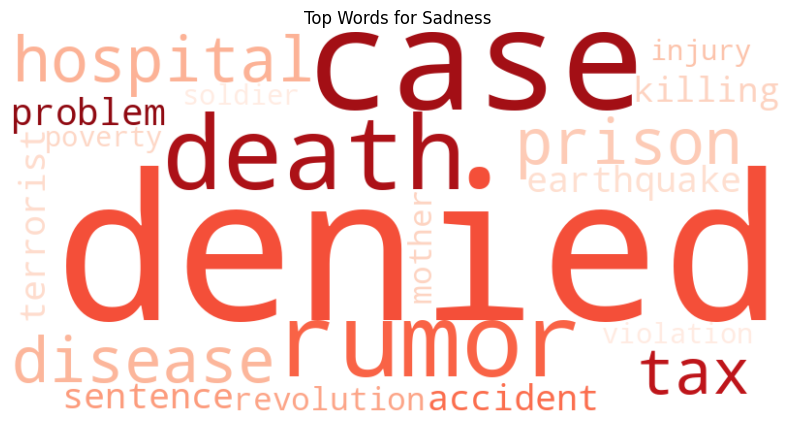

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_sadness_r, target_emotion_sadness)

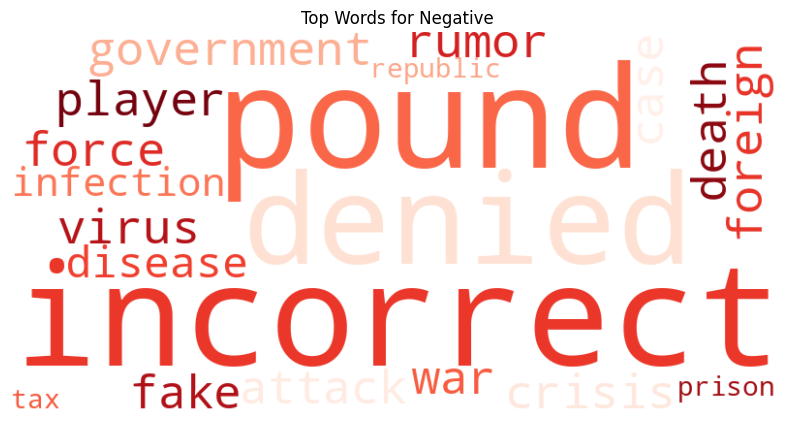

In [ ]:
def generate_word_cloud(top_words, target_emotion):
    wordcloud = WordCloud(background_color='white', colormap='Reds', width=800, height=400).generate(' '.join(top_words))

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Top Words for {target_emotion.capitalize()}')

    plt.show()

generate_word_cloud(top_words_negative_r, target_emotion_negative)